### 1. Setting up our tools
Grabbing the standard data science stack: Pandas and NumPy for crunching numbers and tables, plus Matplotlib and Seaborn to make our charts look clean.

In [1]:
# Import Libraries
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()



### 2. Load the data
Reading the CSV into a DataFrame and printing the first 7 rows to get a quick feel for what columns and values we are dealing with.

In [3]:
# Load Dataset

df = pd.read_csv("Video_Game_Sales_as_of_Jan_2017.csv")

# Display first 7 rows
df.head(7)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.54,76.0,51.0,8.0,324.0,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.80,3.79,3.29,35.57,82.0,73.0,8.3,712.0,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.95,3.28,2.95,32.78,80.0,73.0,8.0,193.0,E
4,Pokemon Red/Pokemon Blue,G,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN
5,Tetris,G,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,NaN,NaN,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.15,6.50,2.88,29.81,89.0,65.0,8.5,433.0,E


### 3. What types of data do we have?
Checking whether columns are numbers, text, or floats so we know what needs formatting later.

In [4]:
# viewing the data types of columns
df.dtypes

Name                   str
Platform               str
Year_of_Release    float64
Genre                  str
Publisher              str
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score         float64
User_Count         float64
Rating                 str
dtype: object

### 4. Hunting down missing values (NaNs)
Checking which columns have empty spots. Looks like scores and ratings have a ton of missing info we'll need to watch out for.

In [5]:
df.isna().sum()

Name                  0
Platform              0
Year_of_Release       8
Genre                 0
Publisher             1
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       9080
Critic_Count       9080
User_Score         9618
User_Count         9618
Rating             7164
dtype: int64

### 5. Checking for duplicates
Checking if any row was accidentally recorded twice. An empty Series here means every single row is unique—clean data!

In [6]:
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### 6. How big is this dataset?
Printing the total size: we're working with 17,416 games and 15 columns of info for each.

In [7]:
print("(Rows, Columns) = ",df.shape)

(Rows, Columns) =  (17416, 15)


### 7. The birds-eye statistical view
Getting the quick summary: averages, min/max values, percentiles for numbers, and the most common values for categories like genres and platforms.

In [8]:
df.describe(include="all")

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
count,17416,17416,17408.000000,17416,17415,17416.000000,17416.000000,17416.000000,17416.000000,17416.000000,8336.000000,8336.000000,7798.000000,7798.000000,10252
unique,12080,31,NaN,12,627,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
top,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
freq,12,2251,NaN,3503,1380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4120
mean,NaN,NaN,2006.630859,NaN,NaN,0.254534,0.140727,0.075020,0.045908,0.516469,68.912548,26.192059,7.117056,162.672480,NaN
std,NaN,NaN,5.901598,NaN,NaN,0.800673,0.497341,0.303412,0.183932,1.526124,13.964937,18.991526,1.502410,562.837954,NaN
min,NaN,NaN,1976.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.000000,4.000000,NaN
25%,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.050000,60.000000,11.000000,6.400000,10.000000,NaN
50%,NaN,NaN,2008.000000,NaN,NaN,0.070000,0.020000,0.000000,0.010000,0.160000,71.000000,21.000000,7.500000,25.000000,NaN
75%,NaN,NaN,2011.000000,NaN,NaN,0.230000,0.100000,0.030000,0.030000,0.450000,79.000000,36.000000,8.200000,81.000000,NaN


### 8. How do top game sales look?
Filtering out the top 200 best-selling games of all time and plotting their global sales distribution. Most cluster on the lower end of the top tier, with a few mega-hits (like Wii Sports) way out on the right.

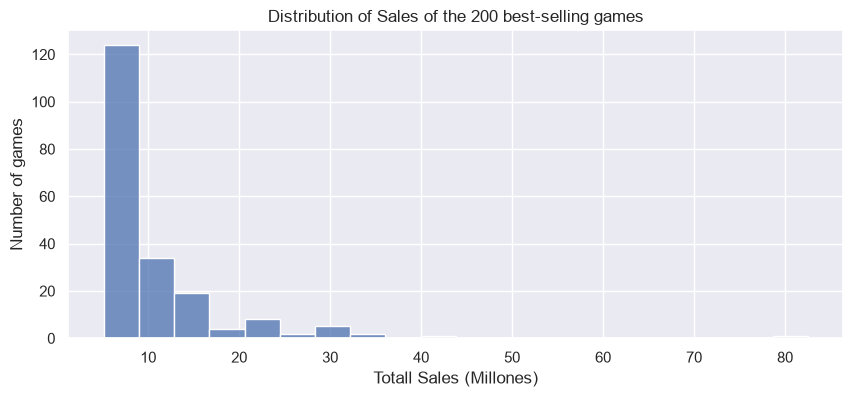

In [9]:

top_200_sales = df["Global_Sales"].nlargest(200)

plt.figure(figsize=(10,4))
sns.histplot(top_200_sales, bins=20)
plt.title("Distribution of Sales of the 200 best-selling games")
plt.xlabel("Totall Sales (Millones)")
plt.ylabel("Number of games")
plt.show()

### 9. Critic scores for the top games
Taking the 200 highest-rated games by reviewers to see their score spread. Most top-tier games land solidly in the mid-80s to low-90s range.

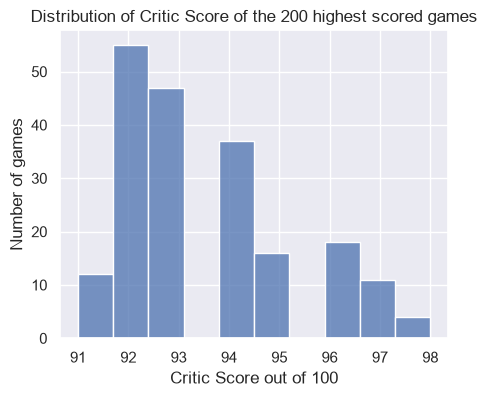

In [10]:

top_200_score = df["Critic_Score"].nlargest(200)

plt.figure(figsize=(5,4))
sns.histplot(top_200_score, bins=10)
plt.title("Distribution of Critic Score of the 200 highest scored games")
plt.xlabel("Critic Score out of 100")
plt.ylabel("Number of games")
plt.show()

### 10. Which consoles sold the most games?
Adding up all global game sales grouped by platform and slapping it on a bar chart to see which consoles dominated gaming history (PS2, PS3, X360, Wii, and DS take the crown).

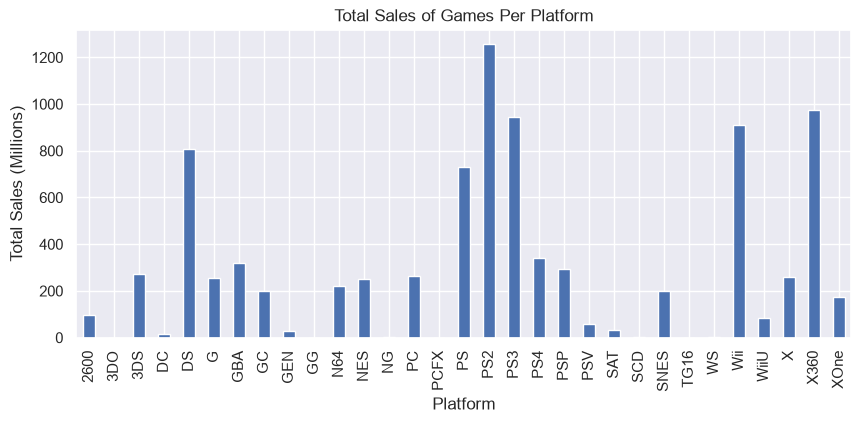

Platform
2600     97.08
3DO       0.10
3DS     270.94
DC       15.97
DS      808.88
Name: Global_Sales, dtype: float64

In [11]:
sale_per_platform = df.groupby("Platform")["Global_Sales"].sum()

plt.figure(figsize=(10,4))
sale_per_platform.plot(kind='bar')
plt.title("Total Sales of Games Per Platform")
plt.ylabel("Total Sales (Millions)")
plt.show()

sale_per_platform.head()

### 11. Most popular game genres
Summing up global sales by genre from highest to lowest. Action and Sports take the lead by a long shot.

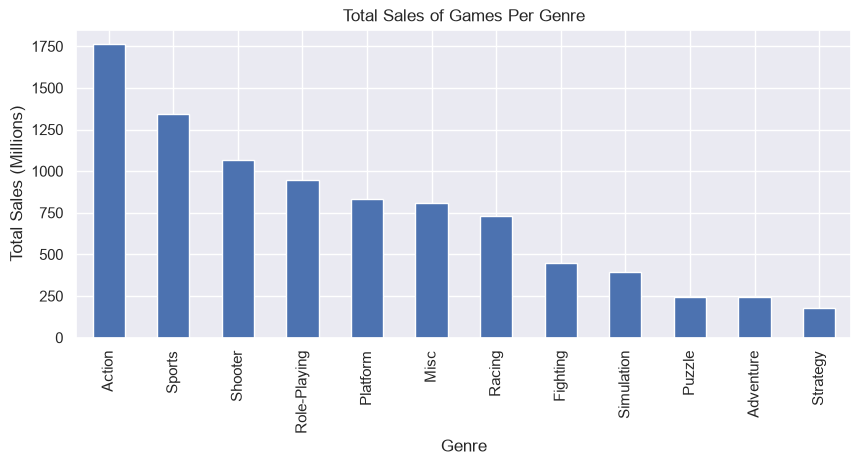

Genre
Action          1761.97
Sports          1341.00
Shooter         1067.30
Role-Playing     949.31
Platform         831.74
Misc             808.80
Racing           731.67
Fighting         449.17
Simulation       392.84
Puzzle           243.76
Adventure        241.55
Strategy         175.72
Name: Global_Sales, dtype: float64

In [12]:
sale_per_platform = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,4))
sale_per_platform.plot(kind='bar')
plt.title("Total Sales of Games Per Genre")
plt.ylabel("Total Sales (Millions)")
plt.show()

sale_per_platform

### 12. Top 20 gaming publishers
Looking at which companies moved the most units globally. Nintendo and EA sit comfortably at the very top.

In [13]:
sale_per_platform = df.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False)


sale_per_platform.head(20)

Publisher
Nintendo                                  1803.00
Electronic Arts                           1132.43
Activision                                 739.98
Sony Computer Entertainment                614.25
Ubisoft                                    477.30
Take-Two Interactive                       408.69
THQ                                        345.51
Konami Digital Entertainment               286.01
Sega                                       272.19
Namco Bandai Games                         258.84
Microsoft Game Studios                     252.11
Capcom                                     200.92
Atari                                      157.67
Warner Bros. Interactive Entertainment     155.04
Square Enix                                150.93
Disney Interactive Studios                 118.08
Eidos Interactive                           98.72
Bethesda Softworks                          87.93
LucasArts                                   85.90
Midway Games                            

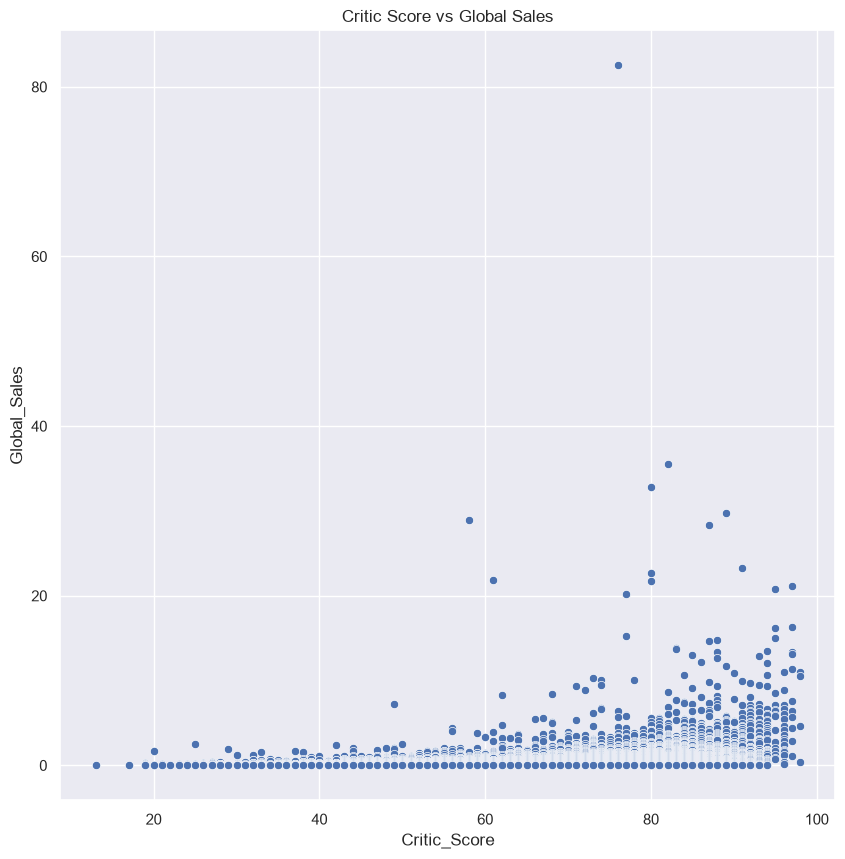

In [14]:
plt.figure(figsize=(10,10))
sns.scatterplot(x='Critic_Score', y="Global_Sales", data=df)
plt.title("Critic Score vs Global Sales")
plt.show()

### 13. Do better review scores mean more sales?
Plotting a quick correlation heatmap between critic scores and global sales. There is a mild positive relationship, but great reviews don't automatically guarantee blockbuster numbers.

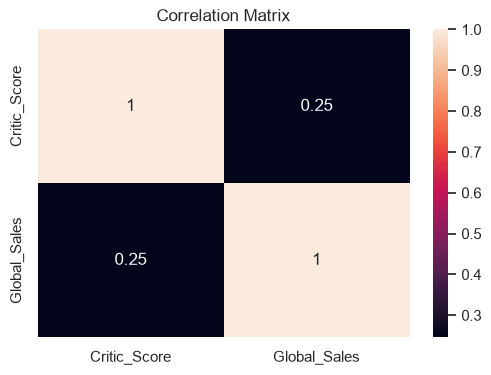

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Critic_Score', 'Global_Sales']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()